# 1. Import libraries

In [2]:
import torch
import torch.nn as nn
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 2. Read dataset

In [2]:
root_dir = 'img_cls_weather_dataset/weather-dataset/dataset'

classes = {
    label_idx: class_name
        for label_idx, class_name in enumerate(
            sorted(os.listdir(root_dir))
        )
}
classes

{0: 'dew',
 1: 'fogsmog',
 2: 'frost',
 3: 'glaze',
 4: 'hail',
 5: 'lightning',
 6: 'rain',
 7: 'rainbow',
 8: 'rime',
 9: 'sandstorm',
 10: 'snow'}

In [3]:
X = []
y = []
for label_idx, class_name in classes.items():
    class_dir = os.path.join(root_dir, class_name)
    for img_filename in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_filename)
        X.append(img_path)
        y.append(label_idx)

X

['img_cls_weather_dataset/weather-dataset/dataset\\dew\\2208.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2209.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2210.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2211.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2212.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2213.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2214.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2215.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2216.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2217.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2218.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2219.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2220.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2221.jpg',
 'img_cls_weather_dataset/weather-dataset/dataset\\dew\\2222.j

# 3. Train, val, test split

In [4]:
seed = 0
val_size = 0.2
test_size = 0.125
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle
)


# 4. Create pytorch datasets

In [5]:
class WeatherDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img_path = self.X[idx]
        label = self.y[idx]

        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label
    
def transform(img):
    resized_img = img.resize((224, 224))
    img_arr = np.array(resized_img)[..., :3]
    # (h, w, c) =. permute() => (c, w, h)
    img_tensor = torch.tensor(img_arr).permute(2, 0, 1).float()
    normalized_img = img_tensor / 255.0

    return normalized_img

train_dataset = WeatherDataset(
    X=X_train,
    y=y_train,
    transform=transform
)

test_dataset = WeatherDataset(
    X=X_test,
    y=y_test,
    transform=transform
)

val_dataset = WeatherDataset(
    X=X_val,
    y=y_val,
    transform=transform
)

# 5. Create dataloader

In [6]:
train_batch_size = 8
test_batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=test_batch_size,
    shuffle=False
)

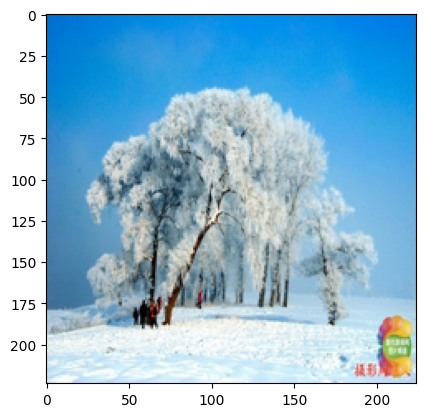

In [7]:
train_imgs, train_labels = next(iter(train_loader))
train_img = train_imgs[0].permute(1, 2, 0)
train_label = train_labels[0].item()
# (c, h, w) =. (h, w, c)
#3 (0, 1, 2) => (1, 2, 0)
plt.imshow(train_img)
plt.show()

# 6. Implement Residual Block (ResNet Architecture)
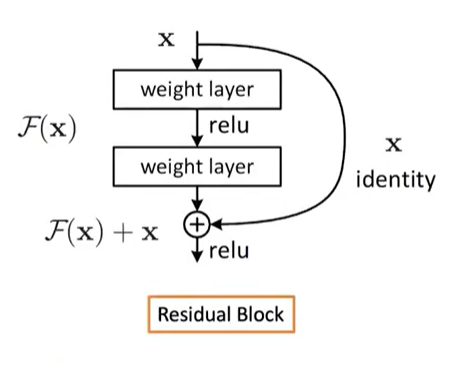

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1
        )
        self.batch_norm1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1
        )
        self.batch_norm2 = nn.BatchNorm2d(out_channels)

        self.downsample = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride
                ),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        res = x.clone()
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = x + self.downsample(res)
        x = self.relu(x)

        return x

# 7. Implement ResNet (ResNet-18)

In [9]:
class ResNet(nn.Module):
    def __init__(self, residual_block, n_block_lst, n_classes):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7, stride=2, padding=3 
        )
        self.batch_norm1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(
            kernel_size=3, stride=2, padding=1
        )

        self.conv2 = self.create_layer(residual_block, 64, 64, n_block_lst[0], 1)
        self.conv3 = self.create_layer(residual_block, 64, 128, n_block_lst[1], 2)
        self.conv4 = self.create_layer(residual_block, 128, 256, n_block_lst[2], 2)
        self.conv5 = self.create_layer(residual_block, 256, 512, n_block_lst[3], 2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512, n_classes)


    def create_layer(self, residual_block, in_channels, out_channels, n_blocks, stride):
        blocks = []
        first_block = residual_block(in_channels, out_channels, stride)
        blocks.append(first_block)

        for _ in range(n_blocks):
            block = residual_block(out_channels, out_channels, stride)
            blocks.append(block)

        layer = nn.Sequential(*blocks)

        return layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.maxpool(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

    
n_block_lst = [2, 2, 2, 2]
n_classes = len(classes.keys())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ResNet(
    ResidualBlock,
    n_block_lst,
    n_classes
).to(device)

model.eval()

dummy_tensor = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    y = model(dummy_tensor)

print(y.shape)


torch.Size([1, 11])


# 8. Training

In [10]:
# Create fit function
def fit(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs
):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        batch_train_losses = []

        model.train()
        for idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss, val_acc = evaluate(
            model, val_loader,
            criterion, device
        )
        val_losses.append(val_loss)

        print(f'EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}')

    return train_losses, val_losses

# Create evaluate function
def evaluate(model, dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = sum(losses) / len(losses)
    acc = correct / total

    return loss, acc

# Training
lr = 1e-2
epochs = 25

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=lr
)

train_losses, val_losses = fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs
)

# Evaluate model
val_loss, val_acc = evaluate(model, val_loader, criterion, device)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print('Evaluation on val/test dataset')
print('Val accuracy: ', val_acc)
print('Test accuracy: ', test_acc)


EPOCH 1:	Train loss: 1.9775	Val loss: 166.8043
EPOCH 2:	Train loss: 1.7637	Val loss: 4736252655033415.0000
EPOCH 3:	Train loss: 1.9586	Val loss: 659.2603
EPOCH 4:	Train loss: 1.9477	Val loss: 8.4355
EPOCH 5:	Train loss: 1.7835	Val loss: 25.6925
EPOCH 6:	Train loss: 1.7871	Val loss: 218092979438558656.0000
EPOCH 7:	Train loss: 2.0557	Val loss: 104729388173931.1562
EPOCH 8:	Train loss: 2.0410	Val loss: 2.0535
EPOCH 9:	Train loss: 1.9288	Val loss: 13574.4784
EPOCH 10:	Train loss: 2.1172	Val loss: 2.3359
EPOCH 11:	Train loss: 1.9846	Val loss: 1.9238
EPOCH 12:	Train loss: 1.9492	Val loss: 136.7969
EPOCH 13:	Train loss: 1.9638	Val loss: 3.5319
EPOCH 14:	Train loss: 1.8725	Val loss: 28.7503
EPOCH 15:	Train loss: 1.9911	Val loss: 2.3292
EPOCH 16:	Train loss: 1.9144	Val loss: 1.8398
EPOCH 17:	Train loss: 1.9058	Val loss: 1.8113
EPOCH 18:	Train loss: 1.8735	Val loss: 1.7526
EPOCH 19:	Train loss: 1.8414	Val loss: 9.7348
EPOCH 20:	Train loss: 1.8319	Val loss: 93.7867
EPOCH 21:	Train loss: 1.8512	V

# 9. Matplotlib

NameError: name 'epochs' is not defined

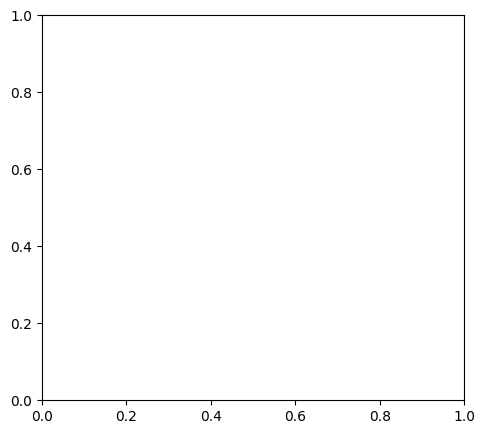

In [3]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, color='blue', linewidth=2, marker='o', label='Train Loss')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss', fontsize=14)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, val_losses, color='orange', linewidth=2, marker='o', label='Validation Loss')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Validation Loss', fontsize=14)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()